In [1]:
# Loan Approval Prediction - Alternative Version

# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('future.no_silent_downcasting', True)

# 2. Load Dataset
loan_data = pd.read_csv("loan_approval_dataset.csv")
loan_data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
# 3. Understand the Data
loan_data.info()
loan_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [4]:
# 4. Data Cleaning

# Remove extra spaces from column names
loan_data.columns = loan_data.columns.str.strip()

# Remove extra spaces from categorical values
cat_cols = loan_data.select_dtypes(include="object").columns
for col in cat_cols:
    loan_data[col] = loan_data[col].str.strip()

# Check missing and duplicate values
print("Missing Values:", loan_data.isnull().sum().sum())
print("Duplicates:", loan_data.duplicated().sum())

# Replace invalid negative residential asset values with 0
loan_data["residential_assets_value"] = loan_data["residential_assets_value"].clip(lower=0)

# Remove unnecessary ID column
loan_data.drop(columns="loan_id", inplace=True)

Missing Values: 0
Duplicates: 0


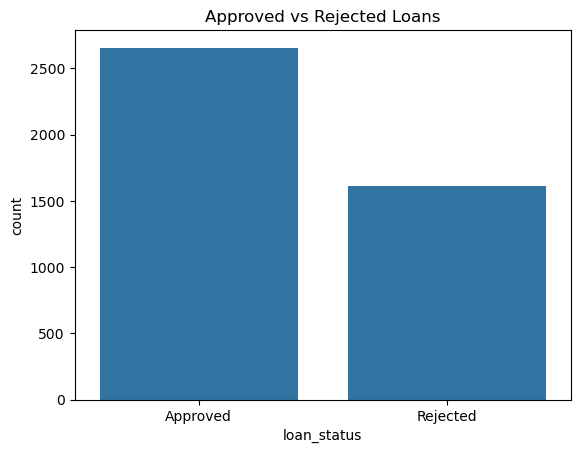

In [5]:
# 5. Exploratory Data Analysis

# Loan status distribution
sns.countplot(data=loan_data, x="loan_status")
plt.title("Approved vs Rejected Loans")
plt.show()

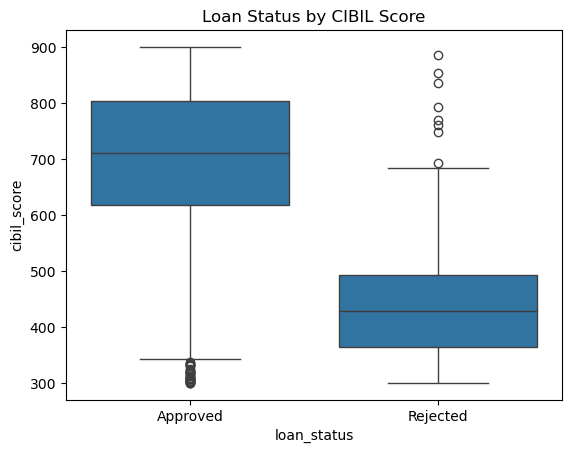

In [6]:
# CIBIL score vs loan status
sns.boxplot(data=loan_data, x="loan_status", y="cibil_score")
plt.title("Loan Status by CIBIL Score")
plt.show()

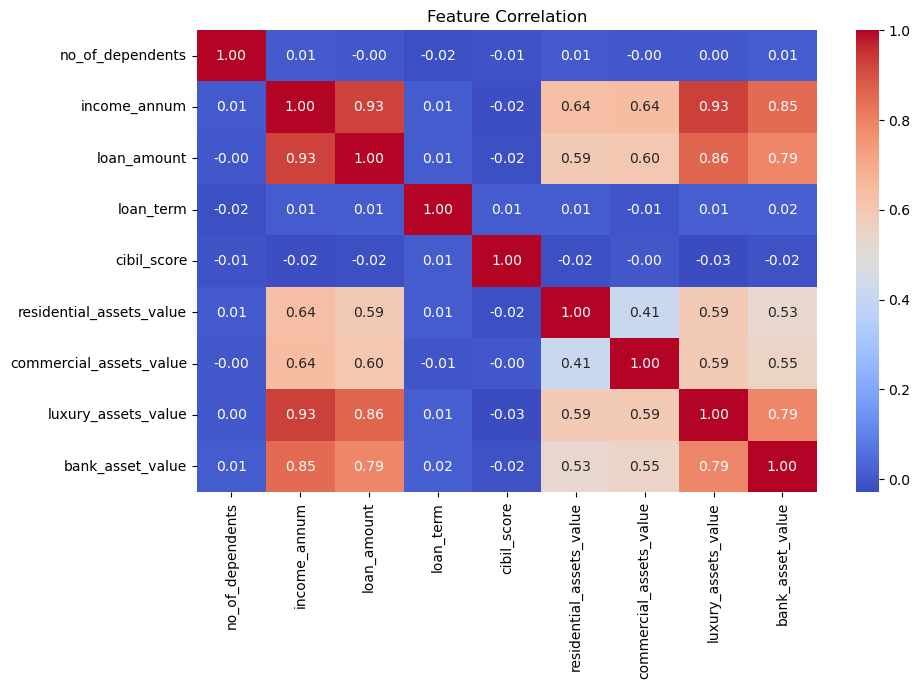

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    loan_data.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Feature Correlation")
plt.show()

In [19]:
# 6. Encode Categorical Data
loan_data.replace({
    "Graduate": 1,
    "Not Graduate": 0,
    "Yes": 1,
    "No": 0,
    "Approved": 1,
    "Rejected": 0
}, inplace=True)

In [10]:
# 7. Features and Target
X = loan_data.drop(columns="loan_status")
y = loan_data["loan_status"]

# 8. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# 9. Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

scale = StandardScaler()
X_train_lr = scale.fit_transform(X_train)
X_test_lr = scale.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_lr, y_train)

log_pred = log_model.predict(X_test_lr)
log_accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.905152224824356


In [12]:
# 10. Decision Tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9742388758782201


In [13]:
# 11. Random Forest
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)
forest_accuracy = accuracy_score(y_test, forest_pred)

print("Random Forest Accuracy:", forest_accuracy)

Random Forest Accuracy: 0.977751756440281


In [14]:
# 12. Compare Models
model_results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

print(model_results)

             Algorithm  Accuracy
0  Logistic Regression  0.905152
1        Decision Tree  0.974239
2        Random Forest  0.977752


              precision    recall  f1-score   support

           0       0.98      0.96      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



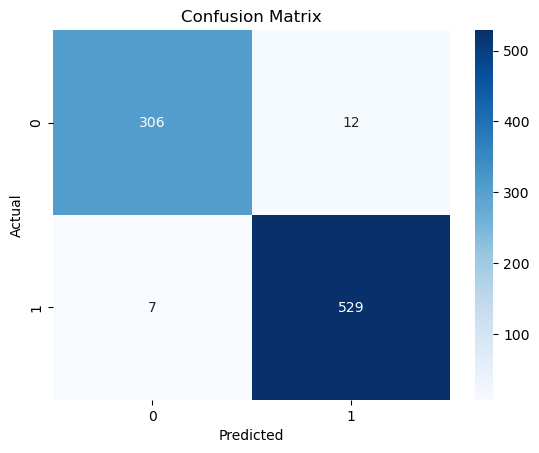

In [15]:
# 13. Evaluate Random Forest
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, forest_pred))

matrix = confusion_matrix(y_test, forest_pred)

sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

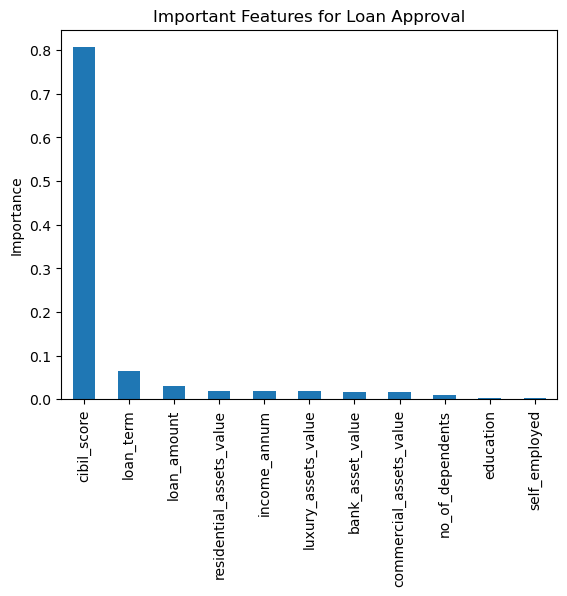

In [16]:
# 14. Feature Importance
feature_imp = pd.Series(
    forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_imp.plot(kind="bar")
plt.title("Important Features for Loan Approval")
plt.ylabel("Importance")
plt.show()


In [17]:
# 15. Predict a New Applicant
applicant = pd.DataFrame([{
    "no_of_dependents": 1,
    "education": 1,
    "self_employed": 1,
    "income_annum": 6000000,
    "loan_amount": 15000000,
    "loan_term": 8,
    "cibil_score": 720,
    "residential_assets_value": 6500000,
    "commercial_assets_value": 4000000,
    "luxury_assets_value": 12000000,
    "bank_asset_value": 5000000
}])

prediction = forest_model.predict(applicant)[0]

if prediction == 1:
    print("Loan Status: Approved")
else:
    print("Loan Status: Rejected")


Loan Status: Approved
